# Decision Tree / Random Forest Model Tree
TODO: finish calculations based on confusion matrix\
store results of each somewhere


## Import Data, libraries, define constants, etc.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
import statistics as stats
import seaborn as sns

url = "https://raw.githubusercontent.com/reganq/csc311-project/refs/heads/main/cleaned_data.csv"
df = pd.read_csv(url)

# separate features for training from validation
df_valid = df[df['is_train'] == False]
df = df[df['is_train'] == True]

# features : array of features in df
features = df.columns.tolist()
features.remove("unique_id")
features.remove('painting')
features.remove('is_train')

PAINTINGS = ["The Persistence of Memory", "The Starry Night", "The Water Lily Pond"]
NUM_TREES = 100


## Function for decision tree

In [2]:
#define function to make tree, called decision tree, from a dataframe X
def decision_tree(df=df, criterion="entropy", max_depth=3, min_samples_leaf=1, max_features="sqrt"):
  """
  run decision tree model on dataframe X
  criterion=criterion, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features
  return the decision tree model that is fit as per the parameters in the function.
  """


  X=df[features]
  t=df["painting"]
  tree = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features)
  tree.fit(X, t)
  return tree

## Function for random forest



In [3]:
def construct_forest(df=df, criterion="entropy", max_depth=3, min_samples_leaf=1, max_features="sqrt", boot_size=100):
  """
  construct random forest, <forest>, in the form of a list of decision trees.
  fit each tree on a unique bootstrapped sample of <df> with replacement and size <boot_size>.
  return <forest>.
  """
  forest = []
  for t in range(NUM_TREES):
    np.random.seed(311)
    df_boot = df.sample(n=boot_size, replace=True)
    forest.append(decision_tree(df=df_boot, criterion=criterion, max_depth=max_depth, min_samples_leaf=min_samples_leaf, max_features=max_features))
  return forest

## Function for Scoring

## Hypeparameter training


In [4]:
# Save to the CSV

hyperparameters = {
    "criterion": [0, 2],
    "max_depth": [1, 16],
    "min_samples_leaf": [1, 15],
    "max_features": [0, 3],
    "boot_size": [len(df)/2, len(df)]
    }
CRITERION = ["gini", "entropy"]
NUM_FEATURES = ["sqrt", "log2", 0.33]

tuning = pd.DataFrame(columns=["Criterion", "Max Depth", "Min Sample Leaf", "Max Features", "Boot Size", "T Acc", "V Acc", "V Pred", "V Rec", "V F1"])
for i in range(3000):
  #for any param_config
  np.random.seed(int(datetime.now().timestamp()))
  c = CRITERION[np.random.randint(hyperparameters["criterion"][0], hyperparameters["criterion"][1])]
  md = np.random.randint(hyperparameters["max_depth"][0], hyperparameters["max_depth"][1])
  msl = np.random.randint(hyperparameters["min_samples_leaf"][0], hyperparameters["min_samples_leaf"][1])
  mf = NUM_FEATURES[np.random.randint(hyperparameters["max_features"][0], hyperparameters["max_features"][1])]
  bs = np.random.randint(hyperparameters["boot_size"][0], hyperparameters["boot_size"][1])
  le = LabelEncoder()
  df["painting"] = le.fit_transform(df["painting"])
  df_valid["painting"] = le.transform(df_valid["painting"])

  np.random.seed(311)
  forest = construct_forest(df=df, criterion=c, max_depth=md, min_samples_leaf=msl, max_features=mf, boot_size=bs)

  votes = np.stack([tree.predict(df[features]) for tree in forest])
  preds = np.apply_along_axis(stats.mode, 0, votes)

  v_votes = np.stack([tree.predict(df_valid[features]) for tree in forest])
  v_preds = np.apply_along_axis(stats.mode, 0, v_votes)

  t_acc = metrics.accuracy_score(df['painting'].to_numpy(), preds)
  v_acc = metrics.accuracy_score(df_valid["painting"].to_numpy(), v_preds)
  v_prec = metrics.precision_score(df_valid["painting"].to_numpy(), v_preds, average="macro")
  v_rec = metrics.recall_score(df_valid["painting"].to_numpy(), v_preds, average="macro")
  v_f1 = metrics.f1_score(df_valid["painting"].to_numpy(), v_preds, average="macro")

  result = pd.DataFrame([{"Criterion" : c, "Max Depth": md, "Min Sample Leaf": msl, "Max Features": mf, "Boot Size": bs, "T Acc": t_acc, "V Acc": v_acc, "V Pred": v_prec, "V Rec": v_rec, "V F1": v_f1}])
  tuning = pd.concat([tuning, result])

pd.DataFrame(tuning).to_csv("results.csv")



/tmp/ipykernel_1062/3365189604.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tuning = pd.concat([tuning, result])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

## Brenden fooling around

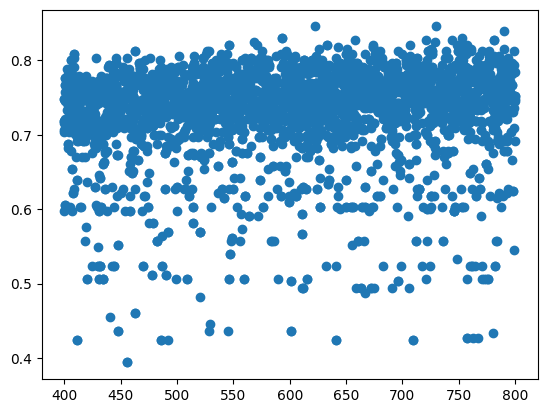

In [5]:
plt.scatter(tuning['Boot Size'], tuning['V Acc'])
plt.show()

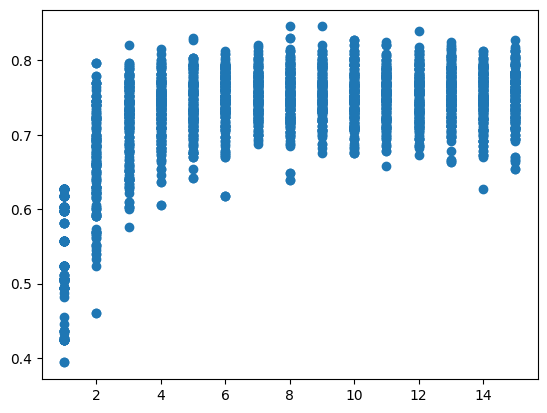

In [6]:
plt.scatter(tuning['Max Depth'], tuning['V Acc'])
plt.show()

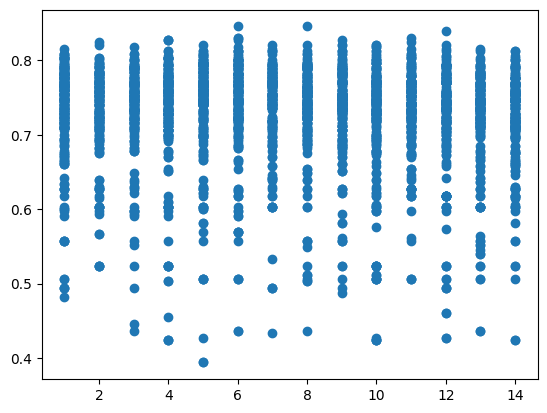

In [7]:
plt.scatter(tuning['Min Sample Leaf'], tuning['V Acc'])
plt.show()


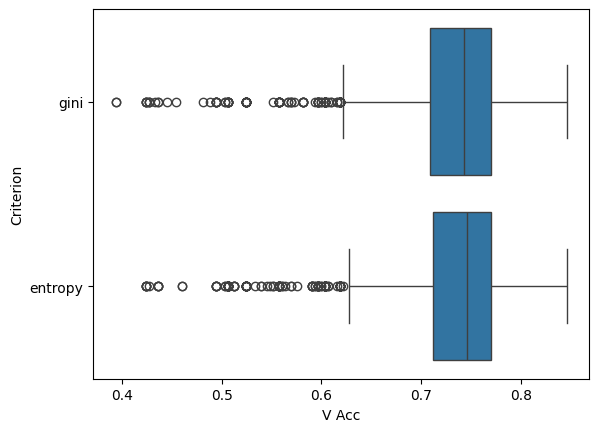

In [8]:
sns.boxplot(data=tuning, x="V Acc", y="Criterion" )
plt.show()

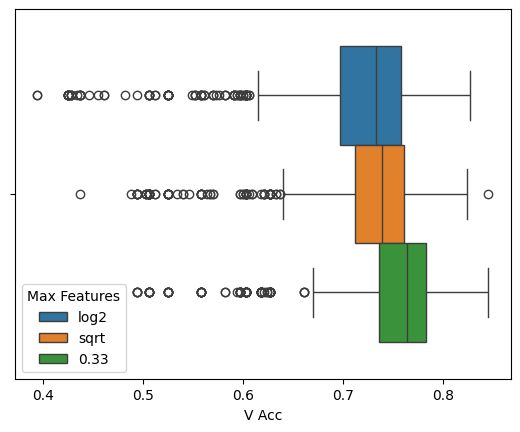

In [9]:
sns.boxplot(data=tuning, x="V Acc", hue="Max Features" )
plt.show()

In [10]:
forest = construct_forest(max_depth=3)
votes = []
for tree in forest:
  votes.append(tree.predict(df[features])[120])
print(votes)
print(stats.mode(votes))

[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)

In [11]:
from sklearn.tree import export_text
text_representation = export_text(forest[2], feature_names=features)
print(text_representation)
tree = forest[5]
left_children = tree.tree_.children_left
right_children = tree.tree_.children_right
feature_splits = tree.tree_.feature # array of the feature index used for splitting
thresholds = tree.tree_.threshold # array of the split points/thresholds

|--- like_spring <= 0.50
|   |--- evokes_calm <= 3.50
|   |   |--- evokes_sombre <= 2.50
|   |   |   |--- class: 1
|   |   |--- evokes_sombre >  2.50
|   |   |   |--- class: 0
|   |--- evokes_calm >  3.50
|   |   |--- text_clock_food <= 0.03
|   |   |   |--- class: 1
|   |   |--- text_clock_food >  0.03
|   |   |   |--- class: 0
|--- like_spring >  0.50
|   |--- text_clock_food <= 0.01
|   |   |--- prominent_colour_count <= 2.50
|   |   |   |--- class: 2
|   |   |--- prominent_colour_count >  2.50
|   |   |   |--- class: 2
|   |--- text_clock_food >  0.01
|   |   |--- text_clock_food <= 0.03
|   |   |   |--- class: 1
|   |   |--- text_clock_food >  0.03
|   |   |   |--- class: 0



In [12]:
feature_splits

array([19,  3,  1, -2, -2, 23, -2, -2, 23,  5, -2, -2, 23, -2, -2],
      dtype=int64)

In [13]:
thresholds

array([ 0.5       ,  3.5       ,  2.5       , -2.        , -2.        ,
        0.03232999, -2.        , -2.        ,  0.00613155,  2.5       ,
       -2.        , -2.        ,  0.03232999, -2.        , -2.        ])

In [14]:
left_children

array([ 1,  2,  3, -1, -1,  6, -1, -1,  9, 10, -1, -1, 13, -1, -1],
      dtype=int64)